# SHAP GAM Models Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import shap

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor

In [2]:
wine = pd.read_csv('wine.csv')
y = wine['quality']
X = wine.drop('quality', axis=1)

In [3]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [5]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = ExplainableBoostingRegressor(interactions=0)
model.fit(X_train, y_train)

ExplainableBoostingRegressor(interactions=0)

In [8]:
y_pred = model.predict(X_test)

In [9]:
mae = mean_absolute_error(y_test, y_pred)

In [10]:
print(f"MAE: {mae:2f}")

MAE: 0.551192


In [11]:
mse = mean_squared_error(y_test, y_pred)

In [12]:
print(f"MSE: {mse:2f}")

MSE: 0.479118


In [13]:
explainer = shap.Explainer(model.predict, X_train)

In [14]:
shap_values = explainer(X_test)

PermutationExplainer explainer: 981it [01:39,  9.65it/s]                                                               


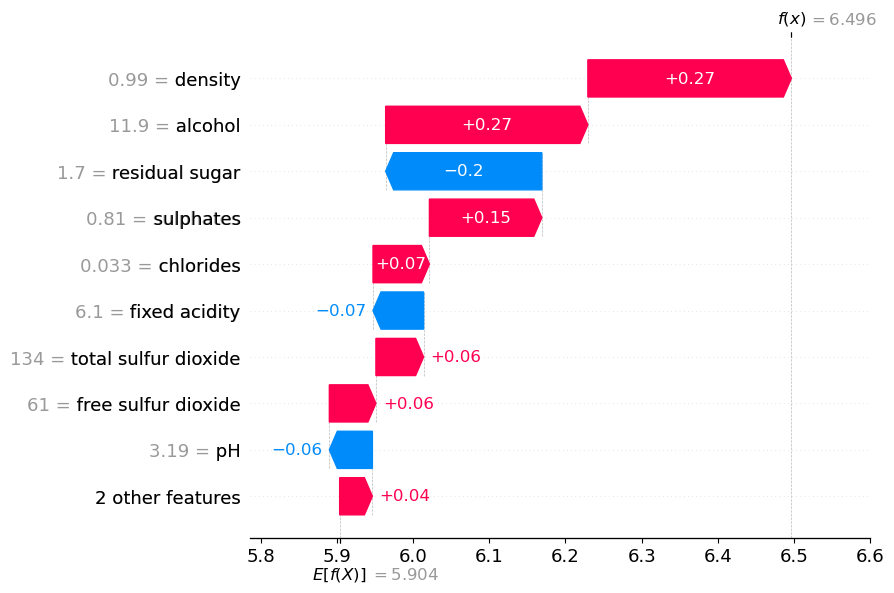

In [15]:
shap.plots.waterfall(shap_values[63], max_display=10)

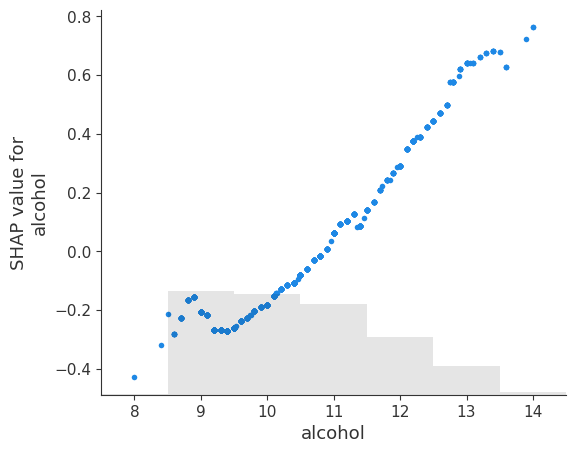

In [16]:
shap.plots.scatter(shap_values[:, "alcohol"])

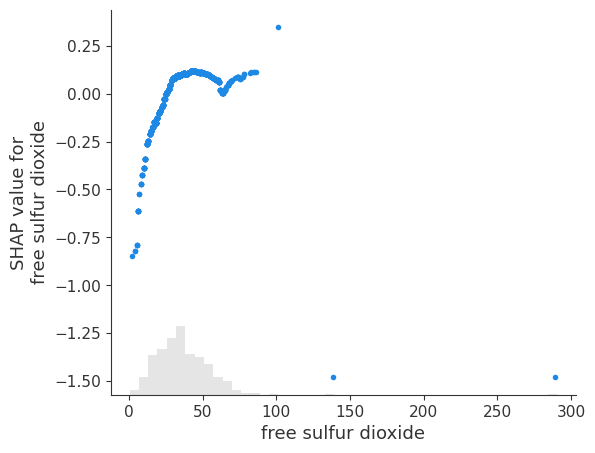

In [17]:
shap.plots.scatter(shap_values[:, "free sulfur dioxide"])

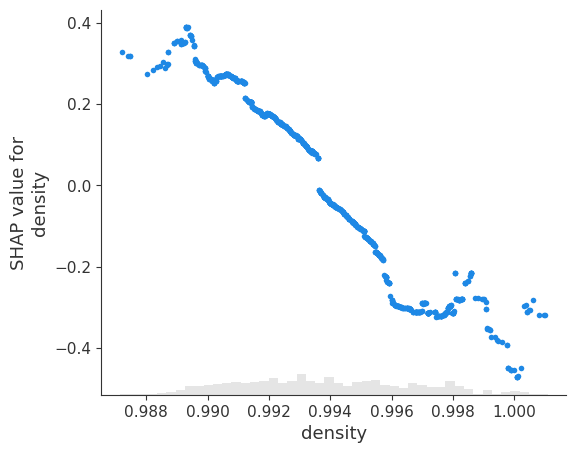

In [18]:
shap.plots.scatter(shap_values[:, "density"])

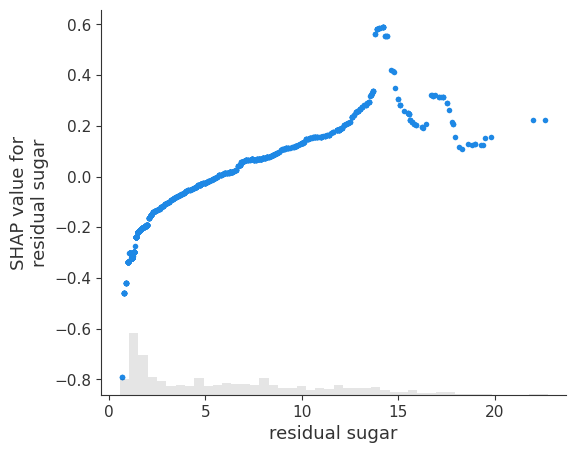

In [19]:
shap.plots.scatter(shap_values[:, "residual sugar"])

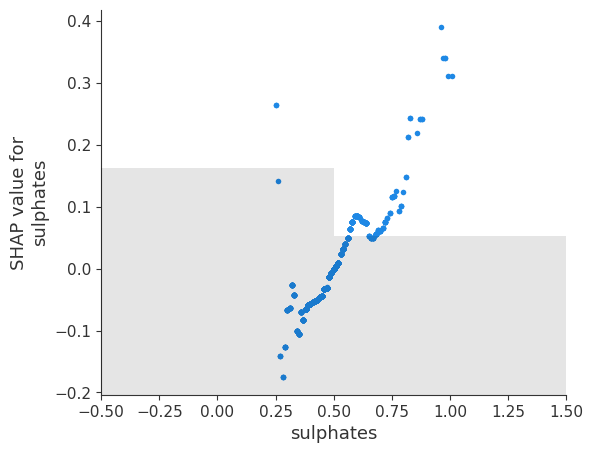

In [20]:
shap.plots.scatter(shap_values[:, "sulphates"])

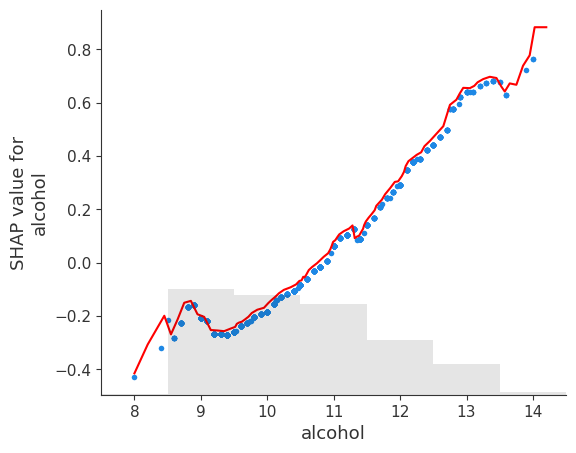

In [21]:
shap.plots.scatter(shap_values[:, "alcohol"], show=False)

# First get the index of the alcohol feature
idx = model.explain_global().data()['names'].index('alcohol')

# Extract the relevant data from the tree based GAM
explain_data = model.explain_global().data(idx)
x_data = explain_data["names"]
y_data = explain_data["scores"]
y_data = np.r_[y_data, y_data[np.newaxis, -1]]

plt.plot(x_data, y_data, color='red')
plt.show()

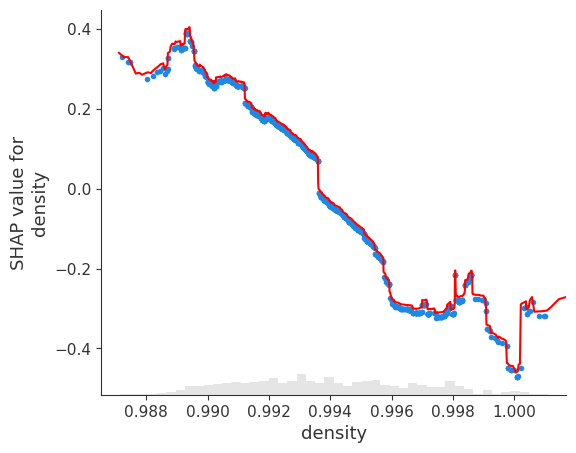

In [22]:
shap.plots.scatter(shap_values[:, "density"], show=False)

# First get the index of the alcohol feature
idx = model.explain_global().data()['names'].index('density')

# Extract the relevant data from the tree based GAM
explain_data = model.explain_global().data(idx)
x_data = explain_data["names"]
y_data = explain_data["scores"]
y_data = np.r_[y_data, y_data[np.newaxis, -1]]

plt.plot(x_data, y_data, color='red')
plt.show()

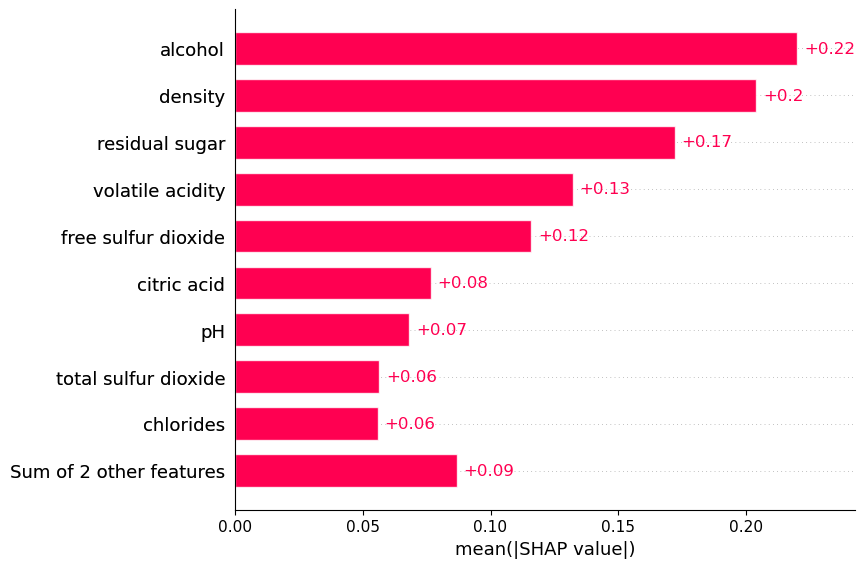

In [23]:
shap.plots.bar(shap_values)